<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit6/EmilChafU6proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Relationship Between Recession and Various Economic Predictors
In this project, using a dataset obtained from Kaggle and measurements that can be argued to measure economic health (such as federal funds rate, INDPRO value, and housing index), I was able to evaluate which combination of these factors and their interactions can best be used to predict the state of the economy.

Data was obtained from Kaggle:
https://www.kaggle.com/datasets/shubhaanshkumar/us-recession-dataset?resource=download

In [7]:
!pip install git+https://github.com/pydata/xarray.git
import xarray as xr
!pip install bambi
import bambi as bmb

  Cloning https://github.com/pydata/xarray.git to /tmp/pip-req-build-ug_7rnkr
  Running command git clone --filter=blob:none --quiet https://github.com/pydata/xarray.git /tmp/pip-req-build-ug_7rnkr
  Resolved https://github.com/pydata/xarray.git to commit ac3b80c2e04cda756268d3e5af19e0159dc9c984
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for xarray: filename=xarray-2026.1.1.dev10+gac3b80c2e-py3-none-any.whl size=1403875 sha256=3a434a13b12955ca52ebd2bc9b63325af2662fa83d2c61db8c699a332db6e320
  Stored in directory: /tmp/pip-ephem-wheel-cache-bargu9u6/wheels/85/31/4d/1461a0a89ce43cb05e88257f443831a509560bcc4d5ebe482c
Successfully built xarray
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.6 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
recessiondata = pd.read_csv('https://raw.githubusercontent.com/emilchafigoulline/Data-Science/refs/heads/main/Unit6/US_Recession.csv')
recessionsdata = recessiondata[['INDPRO', 'Rate', 'Housing_Index', 'GDP']]

In [10]:
recessionsdata

,INDPRO,Rate,Housing_Index,GDP
0,0.046856,0.996359,0.008161,0.000000
1,0.051140,0.986650,0.009267,0.000000
2,0.055858,1.000000,0.010159,0.000000
3,0.053475,0.983010,0.010395,0.002730
4,0.058643,0.980583,0.010048,0.002730
...,...,...,...,...
339,0.967319,0.140777,1.000000,0.955916
340,0.977510,0.197816,0.994871,0.979480
341,0.979829,0.276699,0.979952,0.979480
342,0.986538,0.304612,0.966233,0.979480


This is the Directed Acylclical Graph for my model. For this project, I will test the effects of three different variables on the GDP for the United States, which I am assuming is an accurate indicator of recession. First is INDPRO, which is the measurement of the Industrial Production index, which measures the value of all domestic industrial firms. Next is Rate, which is the federal funds rate. This is the largest economic policy set in place by the Federal Reserve, which regulates currency value using the federal funds rate. Finally is Housing Index, which measures the change in the Housing Price Index, which I believe is an accurate predictor of the Consumer Price Index and likely affects Global Domestic Product.

In [11]:
dag_recession = gv.Digraph(name = 'recession_dag')
dag_recession.node('I', 'INDPRO')
dag_recession.node('R', 'Rate')
dag_recession.node('H', 'Housing_Index')
dag_recession.node('P', 'GDP')
dag_recession.edges(['IP', 'RP', 'HP', 'RI', 'RH' ])

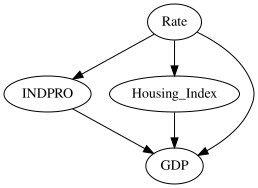

In [12]:
dag_recession

Now, we will need to evaluate which of these factors has the greatest influence on GDP, which we are using as a proxy marker for recession. In order to do this, I will create 5 different models, then test their elpd_loo values against each other according to the actual data to find which is the most optimal:
1. Rate, INDPRO, and Housing_Index all independent
2. All variables with interactions between them (Rate --> Housing Index, Rate --> INDPRO, etc.), two at a time
3. All variables with interactions between Rate & Housing Index
4. All variables with interactions between Rate and INDPRO
5. All variables with interactions between Housing Index and INDPRO



In [ ]:
#all = all independent
model_all = bmb.Model("`GDP` ~ `Rate` + `INDPRO` + `Housing_Index`", data=recessionsdata)
idata_all = model_all.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
#int2 = interactions 2 at a time
model_int2 = bmb.Model("`GDP` ~ `Rate` + `INDPRO` + `Housing_Index` + `Rate` : `INDPRO` + `Rate` : `Housing_Index` + `INDPRO`: `Housing_Index`", data=recessionsdata)
idata_int2 = model_int2.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
#rh = rate --> housing_index
model_rh = bmb.Model("`GDP` ~ `Rate` + `INDPRO` + `Housing_Index` + `Rate` : `Housing_Index`", data=recessionsdata)
idata_rh = model_rh.fit(idata_kwargs={'log_likelihood': True})


(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='Rate', ylabel='GDP'>], dtype=object))

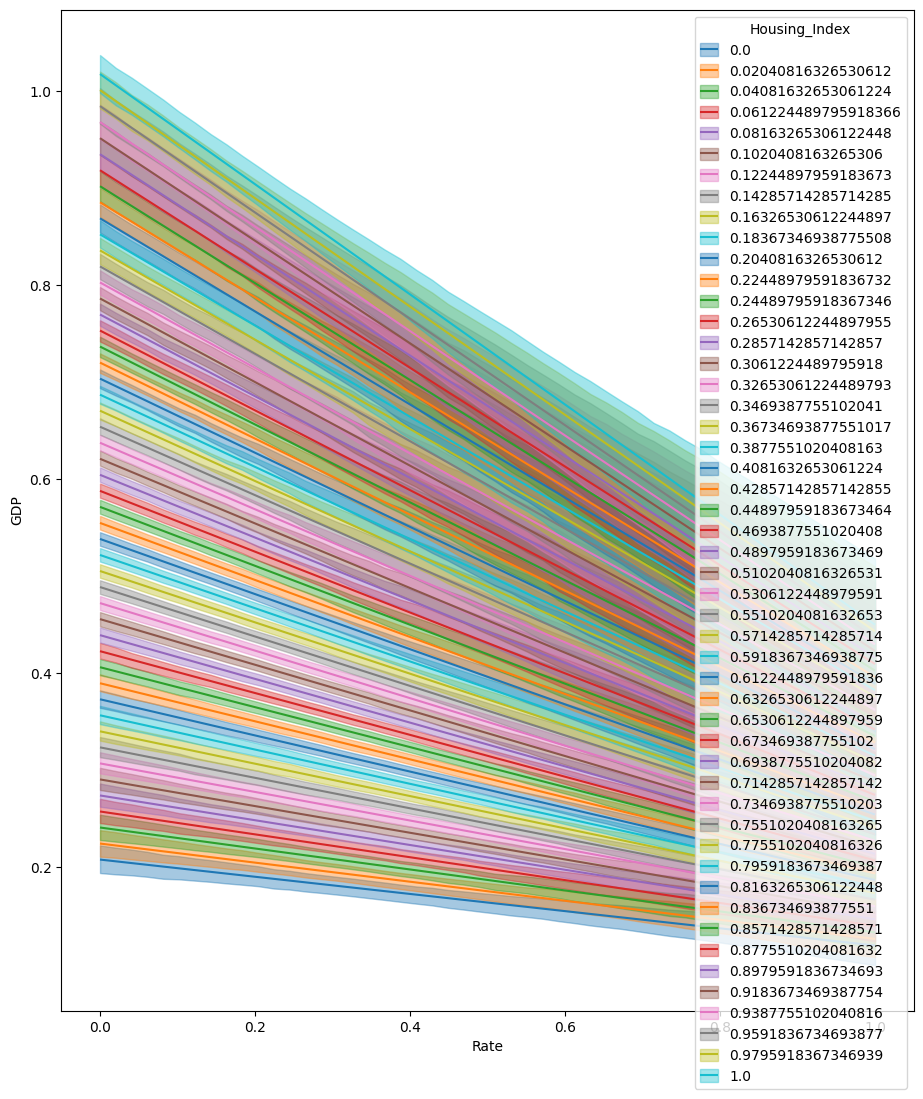

In [16]:
bmb.interpret.plot_predictions(model_rh,
                               idata_rh,
                               ["Rate","Housing_Index"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

In [ ]:
#ri = rate --> INDPRO
model_ri = bmb.Model("`GDP` ~ `Rate` + `INDPRO` + `Housing_Index` + `Rate` : `INDPRO`", data=recessionsdata)
idata_ri = model_ri.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='Rate', ylabel='GDP'>], dtype=object))

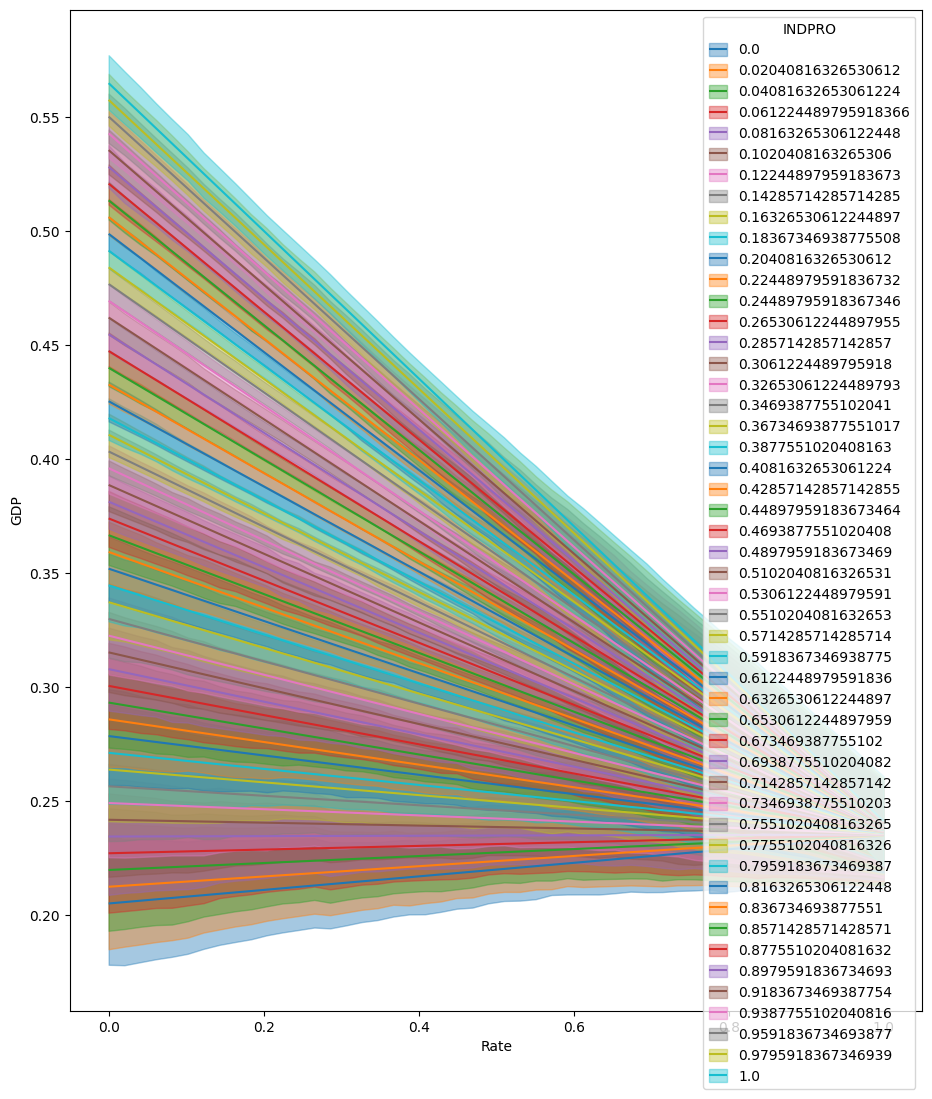

In [18]:
bmb.interpret.plot_predictions(model_ri,
                               idata_ri,
                               ["Rate","INDPRO"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

In [ ]:
#hi = housing index --> INDPRO
model_hi = bmb.Model("`GDP` ~ `Rate` + `INDPRO` + `Housing_Index` + `INDPRO` : `Housing_Index`", data = recessionsdata)
idata_hi = model_hi.fit(idata_kwargs = {'log_likelihood': True})

(<Figure size 1100x1300 with 1 Axes>,
 array([<Axes: xlabel='INDPRO', ylabel='GDP'>], dtype=object))

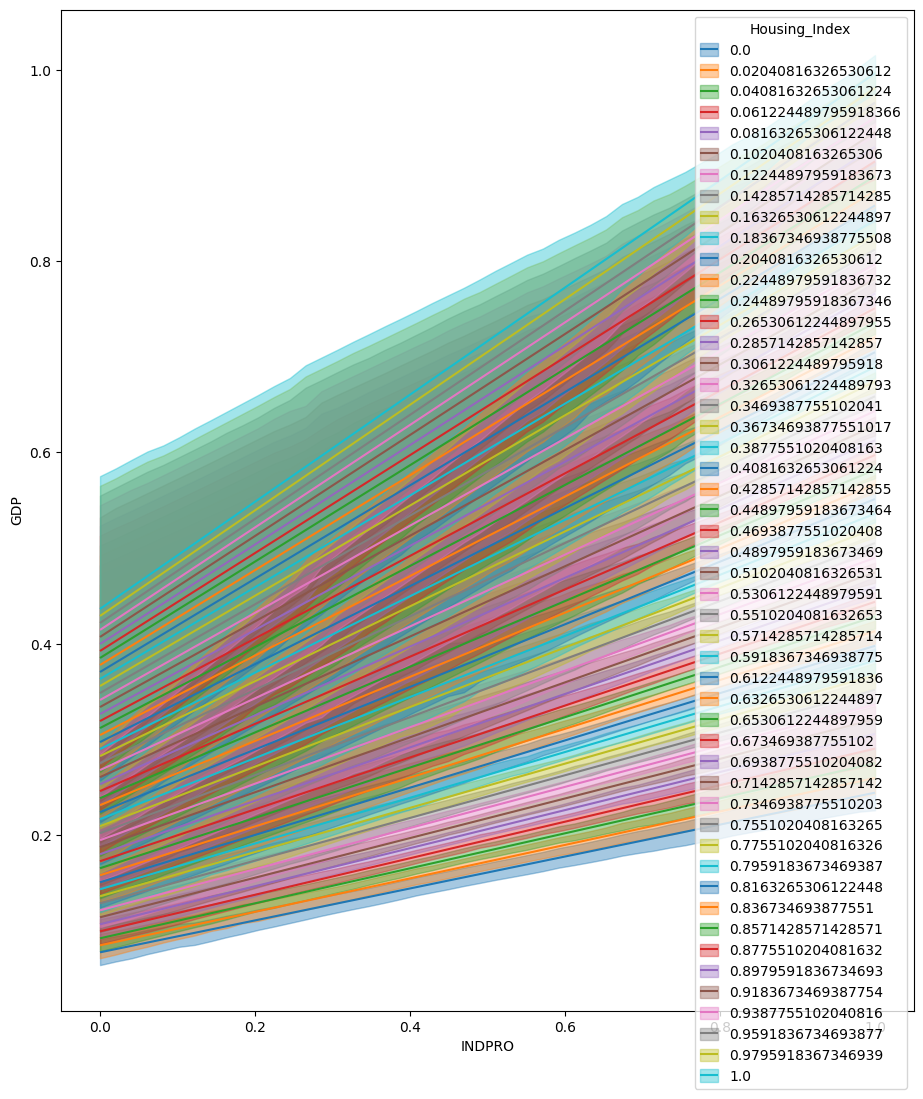

In [20]:
bmb.interpret.plot_predictions(model_hi,
                               idata_hi,
                               ["INDPRO","Housing_Index"],
                               fig_kwargs={"figsize":(11, 13)})#,
                               #legend=False)

In [ ]:
#allint = model_allint --> all interacting
model_allint = bmb.Model("`GDP` ~ `Rate` + `Housing_Index` + `INDPRO` + `Rate` : `Housing_Index` : `INDPRO`", data=recessionsdata)
#fit the model
idata_allint = model_allint.fit(idata_kwargs={'log_likelihood': True})

In [25]:
cmp = az.compare({"seperate":idata_all,"interactions(2 at a time)":idata_int2, "interaction(rate and housingindex)":idata_rh, "interaction(rate and INDPRO)":idata_ri, "interaction(housingindex and INDPRO)":idata_hi, "interactions(all 3 at once)":idata_allint})

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

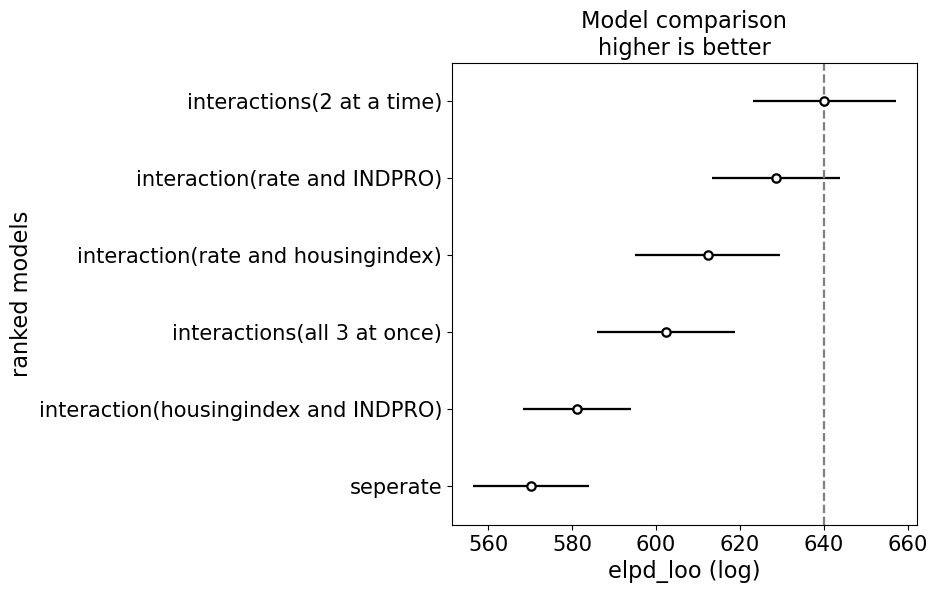

In [26]:
az.plot_compare(cmp)

From this display of the elpd_loo values, we can see that the most effective model is the one with 2 interactions at a time, followed by an interaction between federal funds fate and INDPRO value. The lowest value is that of seperate. This indicates that there is a strong relationship between all three of the variables, with the most impactful one relative to GDP change being the one between Federal Funds Rate and INDPRO value. Meanwhile, other models are not as effective for predicting the value of GDP. Therefore, we can conclude that the best model for prediction of GDP (and therefore recession) includes interactions between all three variables (Rate, Housing Index Price, INDPRO) two at a time.